In [17]:
import os
import random 
import numpy as np
import pandas as pd
import cv2
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import albumentations as A

print("All libraries imported successfully!")


All libraries imported successfully!


# Exploring the Dataset - Date Palm  Diseases

In [13]:
import os
os.chdir(r"C:\DatePalmDisease\Date Palm data")  
print("Current Directory:", os.getcwd())  


Current Directory: C:\DatePalmDisease\Date Palm data


In [31]:
CLASSES = ["healthy", "Brown Spots", "White Scale"]

# Print defined categories
print("\n Disease Categories:")
for cls in CLASSES:
    print(f"{cls}")



 Disease Categories:
healthy
Brown Spots
White Scale



Dataset Summary
Total Images in Dataset: 3582

healthy: 1203 images
Brown Spots: 1170 images
White Scale: 1209 images


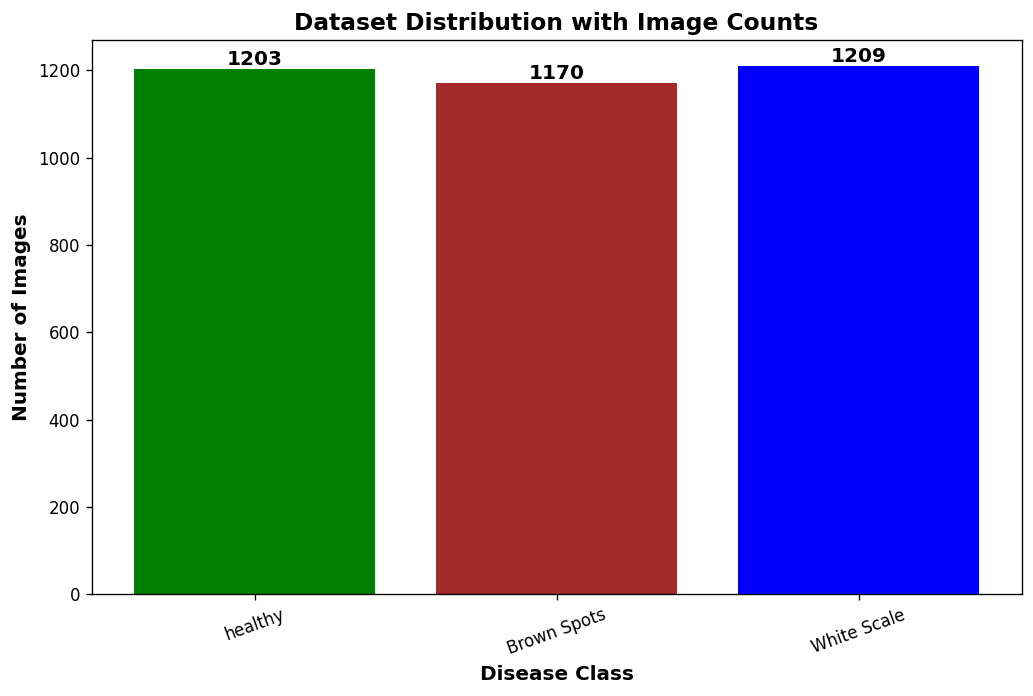

In [7]:
import os
import matplotlib.pyplot as plt

DATASET_PATH = r"C:\DatePalmDisease\Date Palm data"
CLASSES = ["healthy", "Brown Spots", "White Scale"]

def count_images(dataset_path, classes):
    if not os.path.exists(dataset_path):
        raise FileNotFoundError("Error: Dataset path does not exist. Please check the path.")

    class_counts = {}
    for cls in classes:
        class_path = os.path.join(dataset_path, cls.replace("White Scale/", "White Scale"))
        if os.path.exists(class_path):
            class_counts[cls] = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
        else:
            print(f"Warning: Folder '{cls}' not found. Assigning 0 images.")
            class_counts[cls] = 0  
    return class_counts

def plot_class_distribution(class_counts):
    plt.figure(figsize=(10, 6), dpi=120)
    bars = plt.bar(class_counts.keys(), class_counts.values(), color=['green', 'brown', 'blue'])
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, str(int(yval)), ha='center', va='bottom', fontsize=12, fontweight='bold')
    plt.xlabel("Disease Class", fontsize=12, fontweight="bold")
    plt.ylabel("Number of Images", fontsize=12, fontweight="bold")
    plt.title("Dataset Distribution with Image Counts", fontsize=14, fontweight="bold")
    plt.xticks(rotation=20)
    plt.show()

try:
    class_counts = count_images(DATASET_PATH, CLASSES)
    total_images = sum(class_counts.values())
    print("\nDataset Summary")
    print(f"Total Images in Dataset: {total_images}\n")
    for cls, count in class_counts.items():
        print(f"{cls}: {count} images")
    plot_class_distribution(class_counts)
except FileNotFoundError as e:
    print(e)


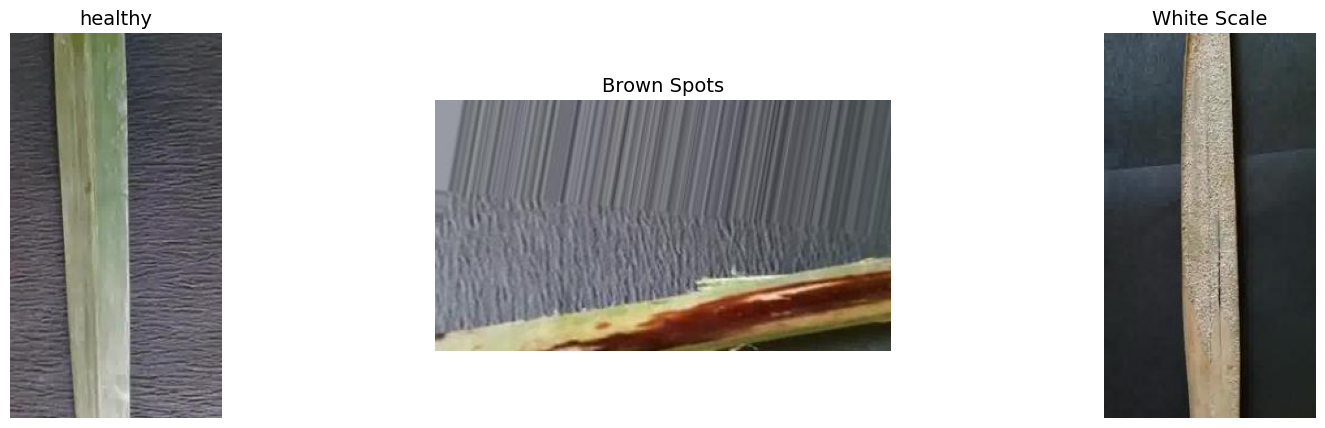

In [9]:
import os
import random
from PIL import Image
DATASET_PATH = r"C:\DatePalmDisease\Date Palm data"
CLASSES = ["healthy", "Brown Spots", "White Scale"]

def visualize_sample_images(dataset_path, classes):
    selected_images = []

    # Loop through each disease category
    for selected_class in classes:  
        class_path = os.path.join(dataset_path, selected_class)
        
        # Get a list of images in the selected class folder
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        
        if not image_files:
            print(f"No images found in '{selected_class}'.")
            continue
        
        # Choose a random image from the list
        selected_image = random.choice(image_files)
        image_path = os.path.join(class_path, selected_image)
        
        # Open the image
        image = Image.open(image_path)
        selected_images.append((selected_class, image))
    
    # Plot the images side by side
    fig, axes = plt.subplots(1, len(selected_images), figsize=(20, 5))
    
    for ax, (class_name, image) in zip(axes, selected_images):
        ax.imshow(image)
        ax.set_title(f"{class_name}", fontsize=14)  # Set title for each class
        ax.axis('off')  # Hide axes for better viewing

    plt.show()

visualize_sample_images(DATASET_PATH, CLASSES)


In [11]:
import cv2
dataset_path = r"C:\DatePalmDisease\Date Palm data"

categories = ["brown spots", "healthy", "white scale"] 

for category in categories:
    folder_path = os.path.join(dataset_path, category)


    if not os.path.exists(folder_path):
        print(f"Warning: {category} folder not found!")
        continue  
        
    found = False
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        
        try:
            img = cv2.imread(img_path)
            if img is not None:
                print(f"{category}: Image shape = {img.shape}")
                found = True
                break  
        except Exception as e:
            print(f"Error reading {img_path}: {e}")
    
    if not found:
        print(f"Warning: No readable images found in {category}!")


brown spots: Image shape = (192, 350, 3)
healthy: Image shape = (350, 192, 3)
white scale: Image shape = (350, 192, 3)


In [5]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_dir = r"C:\DatePalmDisease\Date Palm data"

datagen = ImageDataGenerator(
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)

#  Step 1: Count Images in Each Class BEFORE Augmentation
class_counts_before = {cls: len(os.listdir(os.path.join(dataset_dir, cls))) 
                       for cls in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, cls))}
print("\n Dataset Image Count (Before Augmentation):", class_counts_before)

# Step 2: Find Target Count (Slightly Vary)
target_count = max(class_counts_before.values())  
variation = np.random.randint(-30, 30, len(class_counts_before))  # Small variation for each class

# Step 3: Augment Minority Classes
for i, (cls, count) in enumerate(class_counts_before.items()):
    class_path = os.path.join(dataset_dir, cls)
    new_target = target_count + variation[i]  # Slightly different count for each class

    if count < new_target:  
        num_needed = new_target - count  
        images = [img for img in os.listdir(class_path) if img.endswith((".jpg", ".png"))]
        
        print(f" Augmenting {cls}: Adding ~{num_needed} images")

        i = 0
        while i < num_needed:  
            img_name = np.random.choice(images)  
            img = cv2.imread(os.path.join(class_path, img_name))
            img = np.expand_dims(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), axis=0)
            
            for batch in datagen.flow(img, batch_size=1, save_to_dir=class_path, save_prefix="aug", save_format="jpg"):
                i += 1
                if i >= num_needed:
                    break  

#  Step 4: Count Images AFTER Augmentation
class_counts_after = {cls: len(os.listdir(os.path.join(dataset_dir, cls))) 
                      for cls in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, cls))}
print("\n Dataset Image Count (After Augmentation):", class_counts_after)

# Step 5: Check Balance Status
max_class = max(class_counts_after.values())
min_class = min(class_counts_after.values())

if max_class - min_class <= 50:  
    print("\n  Dataset is now BALANCED")
else:
    print("\n  Dataset is still IMBALANCED")



 Dataset Image Count (Before Augmentation): {'brown spots': 470, 'healthy': 1203, 'white scale': 958}
 Augmenting brown spots: Adding ~727 images
 Augmenting white scale: Adding ~253 images

 Dataset Image Count (After Augmentation): {'brown spots': 1170, 'healthy': 1203, 'white scale': 1209}

  Dataset is now BALANCED


Augmented images...



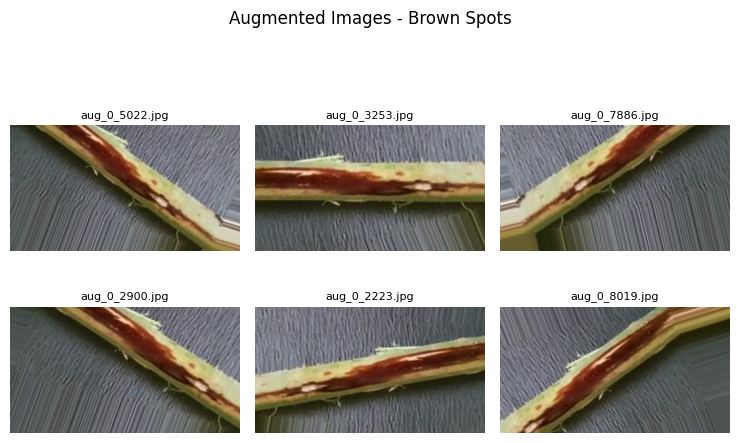

No augmented images found in C:\DatePalmDisease\Date Palm data\healthy


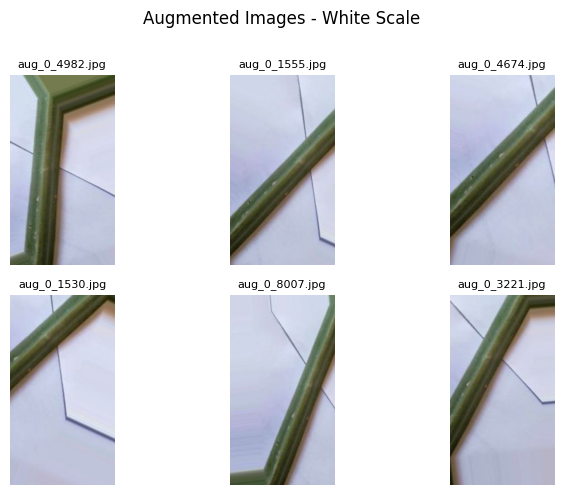

In [53]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

dataset_dir = r"C:\DatePalmDisease\Date Palm data"

def show_augmented_samples(class_dir, num_samples=6):
    aug_images = [img for img in os.listdir(class_dir) 
                  if img.lower().endswith(".jpg") and img.startswith("aug")]
    
    if len(aug_images) == 0:
        print(f"No augmented images found in {class_dir}")
        return

    selected_images = np.random.choice(aug_images, size=min(num_samples, len(aug_images)), replace=False)

    # Smaller layout: 2 rows, 3 columns
    rows = 2
    cols = math.ceil(num_samples / rows)

    plt.figure(figsize=(cols * 2.5, rows * 2.5))  # Smaller figure size for PPT
    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(img_name, fontsize=8)
        plt.axis('off')
        
    class_name = os.path.basename(class_dir).strip().title()
    plt.suptitle(f"Augmented Images - {class_name}", fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Leave space for suptitle
    plt.show()

print("Augmented images...\n")

for cls in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, cls)
    if os.path.isdir(class_path):
        show_augmented_samples(class_path, num_samples=6)


# Image Processing 
# Feature Extraction using glcm and hsv 


In [11]:
# Define dataset path
import os
dataset_path = r"C:\DatePalmDisease\Date Palm data"
processed_path = r"C:\DatePalmDisease\Processed"

categories = {
    "healthy": os.path.join(dataset_path, "healthy"),
    "brown spots": os.path.join(dataset_path, "brown spots"),
    "white scale": os.path.join(dataset_path, "white scale")
}

# Ensure processed folder exists
os.makedirs(processed_path, exist_ok=True)

print("Dataset paths set up correctly!")


Dataset paths set up correctly!


In [1]:
import os
import shutil
import random

dataset_dir = r"C:\DatePalmDisease\Date Palm data"
output_dir = r"C:\DatePalmDisease\Split_Data"
train_dir = os.path.join(output_dir, "train")
test_dir = os.path.join(output_dir, "test")

# Create directories
for split in [train_dir, test_dir]:
    for cls in os.listdir(dataset_dir):
        os.makedirs(os.path.join(split, cls), exist_ok=True)

# Split ratio
train_ratio = 0.8  

# Split images into train/test
for cls in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, cls)
    images = [img for img in os.listdir(class_path) if img.endswith((".jpg", ".png"))]
    random.shuffle(images)

    split_idx = int(len(images) * train_ratio)
    train_images, test_images = images[:split_idx], images[split_idx:]

    # Copy images to respective folders
    for img in train_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_dir, cls, img))
    
    for img in test_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(test_dir, cls, img))

print("\n Train-Test Split Completed Successfully!")



 Train-Test Split Completed Successfully!


In [1]:
import os
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Define dataset and save paths
dataset_path = r"C:\DatePalmDisease\Date Palm data"
save_path = r"C:\DatePalmDisease\ml_new"
os.makedirs(save_path, exist_ok=True)

# Define GLCM parameters
distances = [1, 3, 5, 7]  
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]  
properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']

def compute_glcm_features(gray_image):
    """ Compute GLCM features from a grayscale image """
    if gray_image is None:
        return np.zeros(len(properties) * len(distances) * len(angles))  # Correct feature length
    
    glcm = graycomatrix(gray_image, distances=distances, angles=angles, symmetric=True, normed=True)
    features = [graycoprops(glcm, prop).flatten() for prop in properties]
    
    return np.concatenate(features)

def compute_hsv_features(hsv_image):
    """ Compute HSV color features (mean & std) """
    if hsv_image is None:
        return np.zeros(6)  

    h, s, v = cv2.split(hsv_image)
    return np.array([np.mean(h), np.std(h), np.mean(s), np.std(s), np.mean(v), np.std(v)])

# Feature storage
features_glcm, features_glcm_hsv, labels = [], [], []

# Process images
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        if img_path.lower().endswith((".jpg", ".png", ".jpeg")):
            img = cv2.imread(img_path)
            if img is None:
                print(f" Skipping unreadable image: {img_path}")
                continue  

            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

            glcm_features = compute_glcm_features(img_gray)
            hsv_features = compute_hsv_features(img_hsv)

            features_glcm.append(glcm_features)
            features_glcm_hsv.append(np.concatenate([glcm_features, hsv_features]))
            labels.append(class_name)

# Convert to numpy arrays
X_glcm = np.array(features_glcm)
X_glcm_hsv = np.array(features_glcm_hsv)
y = np.array(labels)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Save label mapping
np.save(os.path.join(save_path, "label_classes.npy"), label_encoder.classes_)

# Print dataset shape
print(f" Feature Extraction Completed! Shape: {X_glcm.shape}, Labels: {y_encoded.shape}")

# Train-Test Split
X_train_glcm, X_test_glcm, y_train_glcm, y_test_glcm = train_test_split(
    X_glcm, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)
X_train_glcm_hsv, X_test_glcm_hsv, y_train_glcm_hsv, y_test_glcm_hsv = train_test_split(
    X_glcm_hsv, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Save train-test split data
np.save(os.path.join(save_path, "X_train_glcm.npy"), X_train_glcm)
np.save(os.path.join(save_path, "X_test_glcm.npy"), X_test_glcm)
np.save(os.path.join(save_path, "y_train_glcm.npy"), y_train_glcm)
np.save(os.path.join(save_path, "y_test_glcm.npy"), y_test_glcm)

np.save(os.path.join(save_path, "X_train_glcm_hsv.npy"), X_train_glcm_hsv)
np.save(os.path.join(save_path, "X_test_glcm_hsv.npy"), X_test_glcm_hsv)
np.save(os.path.join(save_path, "y_train_glcm_hsv.npy"), y_train_glcm_hsv)
np.save(os.path.join(save_path, "y_test_glcm_hsv.npy"), y_test_glcm_hsv)

print(f" Extracted features saved to: {save_path}")


 Feature Extraction Completed! Shape: (3582, 80), Labels: (3582,)
 Extracted features saved to: C:\DatePalmDisease\ml_new


# #Reading & Resizing the Image

Images resized, normalized, and saved to C:\DatePalmDisease\cnn_resized_images.npz


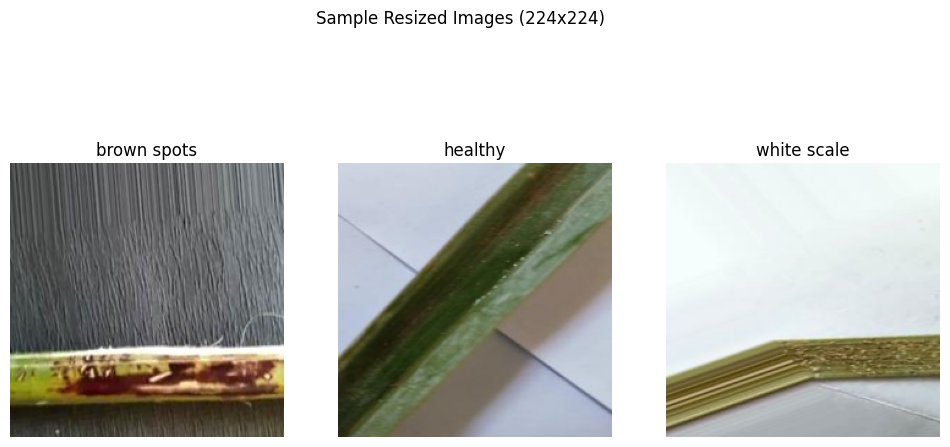

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths
dataset_dir = r"C:\DatePalmDisease\Date Palm data"  
output_npz = r"C:\DatePalmDisease\cnn_resized_images.npz"

# Image size
IMG_SIZE = (224, 224)

# Load and process images
image_data, labels = [], []
class_samples = {}  # To store one sample per class

for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        if img_path.endswith((".jpg", ".png", ".jpeg")):
            img = cv2.imread(img_path)
            img = cv2.resize(img, IMG_SIZE)  
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
            img = img.astype(np.float32) / 255.0  

            # Append image and label
            image_data.append(img)
            labels.append(class_name)

            # Store first image of each class
            if class_name not in class_samples:
                class_samples[class_name] = img

# Save processed images
np.savez(output_npz, images=np.array(image_data), labels=np.array(labels))
print(f"Images resized, normalized, and saved to {output_npz}")

# Display sample images from each class
plt.figure(figsize=(12, 6))
for i, (class_name, sample_img) in enumerate(class_samples.items()):
    plt.subplot(1, len(class_samples), i + 1)
    plt.imshow(sample_img)
    plt.axis('off')
    plt.title(class_name)

plt.suptitle(" Resized Images (224x224)")
plt.show()


# Convert the Color

Processing Classes: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:19<00:00,  6.66s/it]


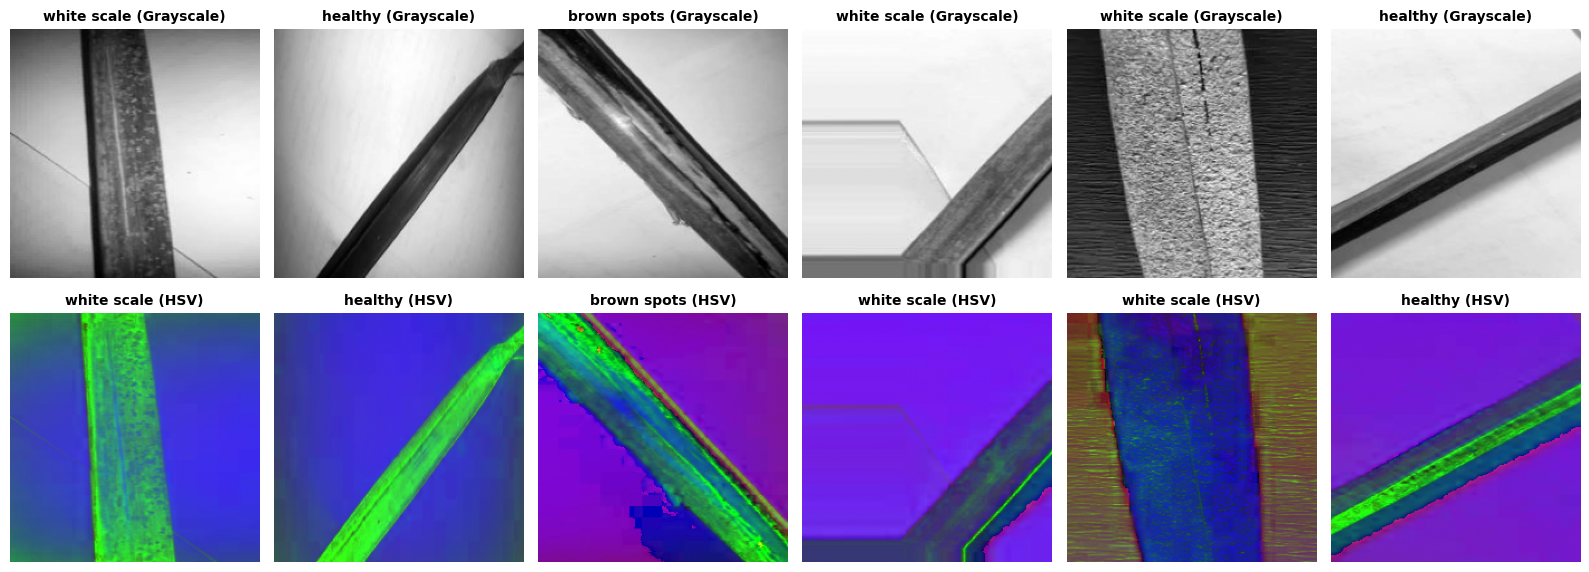

In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

input_folder = "C:\DatePalmDisease\Date Palm data"  
img_size = (224, 224) 


grayscale_images = []
hsv_images = []
image_labels = []

def convert_color_spaces(input_path, target_size):
    class_names = os.listdir(input_path)  
    
    for class_name in tqdm(class_names, desc="Processing Classes"):
        class_path = os.path.join(input_path, class_name)
        
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                # Load Image and Convert to RGB
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
                
                # Resize to 224x224
                img = cv2.resize(img, target_size)

                # Convert to Grayscale
                gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
                
                # Convert to HSV
                hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

                # Normalize Pixel Values (0-1 scaling)
                gray_img = gray_img / 255.0  
                hsv_img = hsv_img / 255.0  

                # Store Processed Images and Labels
                grayscale_images.append(gray_img)
                hsv_images.append(hsv_img)
                image_labels.append(class_name)
                
            except Exception as e:
                print(f"Error processing {img_name}: {e}")

convert_color_spaces(input_folder, img_size)

grayscale_images = np.array(grayscale_images)
hsv_images = np.array(hsv_images)
image_labels = np.array(image_labels)

def display_grayscale_hsv_samples(grayscale, hsv, labels, num_images=6):
    unique_classes = list(set(labels))
    sample_indices = []

    for class_name in unique_classes:
        class_indices = [i for i, label in enumerate(labels) if label == class_name]
        if class_indices:
            sample_indices.append(random.choice(class_indices))
        if len(sample_indices) >= num_images:
            break

    while len(sample_indices) < num_images:
        sample_indices.append(random.randint(0, len(grayscale) - 1))

    fig, axes = plt.subplots(2, num_images, figsize=(16, 6))

    for i, idx in enumerate(sample_indices):
        axes[0, i].imshow(grayscale[idx], cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title(labels[idx] + " (Grayscale)", fontsize=10, fontweight="bold")

        axes[1, i].imshow(hsv[idx])
        axes[1, i].axis("off")
        axes[1, i].set_title(labels[idx] + " (HSV)", fontsize=10, fontweight="bold")

    plt.tight_layout()
    plt.show()
    
display_grayscale_hsv_samples(grayscale_images, hsv_images, image_labels, num_images=6)


# Appending the Image and Labels

In [3]:
import numpy as np
import os
import cv2
from tqdm import tqdm

input_folder = "C:\DatePalmDisease\Date Palm data" 
img_size = (224, 224)  


grayscale_images = []
hsv_images = []
image_labels = []


def load_images_for_ml(input_path, target_size):
    class_names = os.listdir(input_path) 
    label_map = {class_name: idx for idx, class_name in enumerate(class_names)}  

    for class_name in tqdm(class_names, desc="Processing Classes"):
        class_path = os.path.join(input_path, class_name)
        
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
               
                img = cv2.resize(img, target_size)

                gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
                
                hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

                gray_img = gray_img / 255.0  
                hsv_img = hsv_img / 255.0  

                grayscale_images.append(gray_img)
                hsv_images.append(hsv_img)
                image_labels.append(label_map[class_name])  
                
            except Exception as e:
                print(f"Error processing {img_name}: {e}")


load_images_for_ml(input_folder, img_size)

grayscale_images = np.array(grayscale_images).reshape(-1, 224, 224, 1) 
hsv_images = np.array(hsv_images).reshape(-1, 224, 224, 3)
image_labels = np.array(image_labels)

print("\n Image & Label Processing Completed!")
print(f"Total Processed Images: {len(grayscale_images)}")
print(f"Unique Classes: {np.unique(image_labels)}")
print(f"Grayscale Image Shape: {grayscale_images.shape}")
print(f"HSV Image Shape: {hsv_images.shape}")
print(f"Labels Shape: {image_labels.shape}")


Processing Classes: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:14<00:00,  4.74s/it]



 Image & Label Processing Completed!
Total Processed Images: 3582
Unique Classes: [0 1 2]
Grayscale Image Shape: (3582, 224, 224, 1)
HSV Image Shape: (3582, 224, 224, 3)
Labels Shape: (3582,)
